In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load Dataset

In [4]:
df=pd.read_csv("data.csv")

In [5]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handle Missing Values

In [6]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [7]:
from sklearn.impute import SimpleImputer

num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [9]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

# EDA - Exploratory data analysis

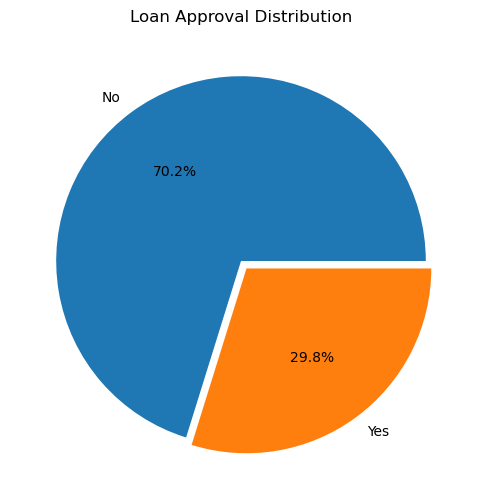

In [10]:
# How balance our classes are
classes_count = df["Loan_Approved"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(classes_count,
        labels=classes_count.index,
        autopct="%1.1f%%",
        
        explode=[0, 0.05])   # Explode second slice (No)

plt.title("Loan Approval Distribution")
plt.show()


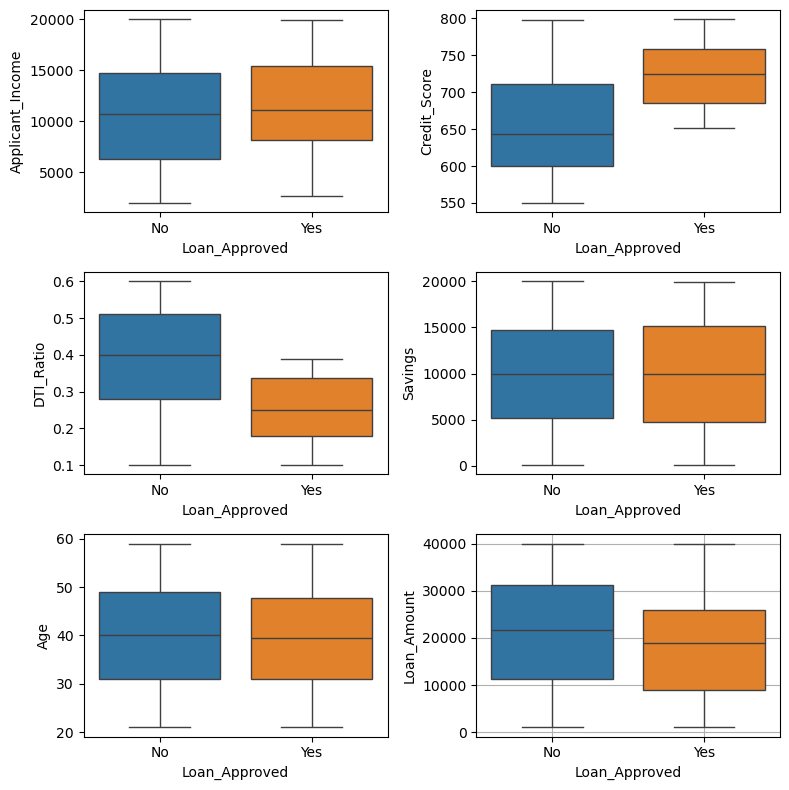

In [11]:
# Outliers-box plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(8, 8))

sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income",hue="Loan_Approved")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score",hue="Loan_Approved")

sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio",hue="Loan_Approved")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Savings",hue="Loan_Approved")

sns.boxplot(ax=axes[2,0], data=df, x="Loan_Approved", y="Age",hue="Loan_Approved")
sns.boxplot(ax=axes[2,1], data=df, x="Loan_Approved", y="Loan_Amount",hue="Loan_Approved")
plt.grid(True)
plt.tight_layout()
plt.show()

<Axes: xlabel='Credit_Score', ylabel='Count'>

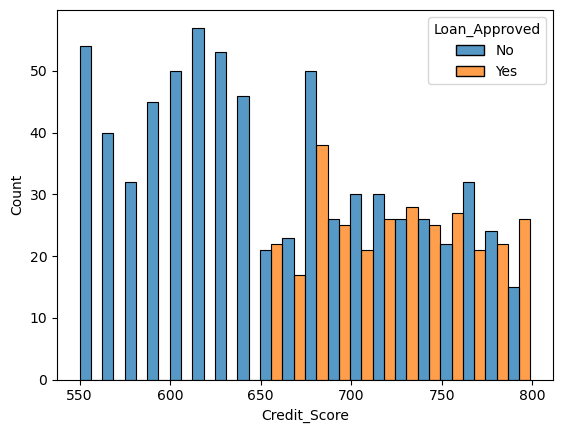

In [12]:
# Credit score with Loan Approved
sns.histplot(
    data=df,
    x="Credit_Score",
    
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)


In [13]:
df = df.drop(columns=["Applicant_ID"], errors="ignore")

# Encoding

In [14]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [15]:
# sklearn label encoder
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


In [22]:
# sklearn OneHot Encoder
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

# Corelation Heatmap

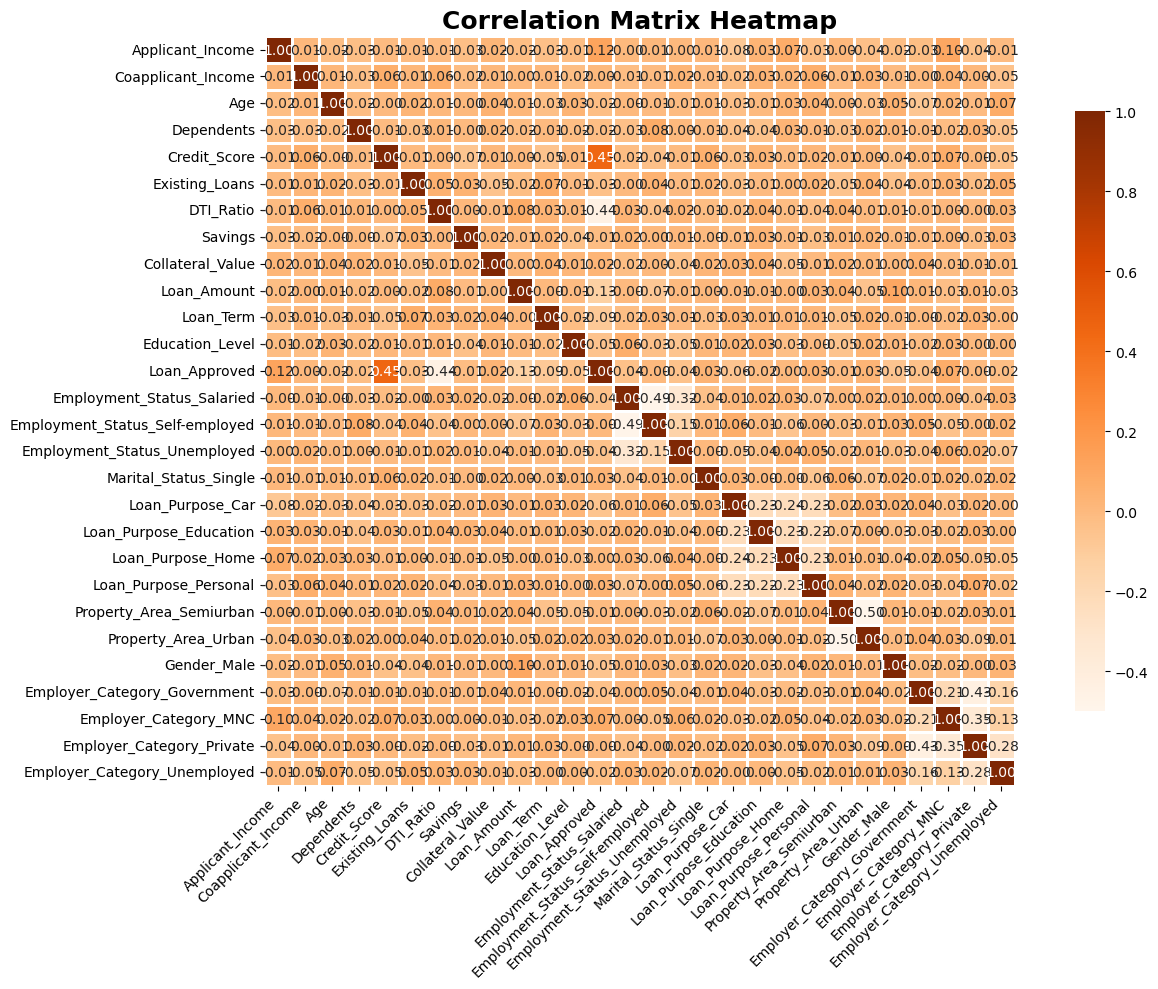

In [36]:
# Set figure size (Large Size)
plt.figure(figsize=(14,10))

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Oranges",        # Attractive color (try: 'viridis', 'plasma', 'cubehelix')
    linewidths=1,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

# Title styling
plt.title("Correlation Matrix Heatmap", fontsize=18, fontweight='bold')

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [28]:
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Train-Test-Split + Feature Scaling

In [37]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [39]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [42]:
X_train,X_test,y_train,y_test =train_test_split(
    X,y,test_size=0.2,random_state=42
)   

In [46]:
X_test.sample(4)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
327,10311.0,7059.0,40.0,0.0,761.0,4.0,0.57,12714.000000,13453.0,1306.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
753,8233.0,1798.0,31.0,2.0,722.0,3.0,0.13,6026.000000,32499.0,14880.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
578,12015.0,7029.0,54.0,2.0,691.0,4.0,0.57,19333.000000,24509.0,28690.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
810,5687.0,1241.0,24.0,3.0,582.0,2.0,0.17,9940.452632,13546.0,37048.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [47]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [48]:
X_test_Scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Train & Evaluate Models

# Logistic Regression Model

In [53]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model=LogisticRegression()
log_model.fit(X_train_Scaled,y_train)

y_pred=log_model.predict(X_test_Scaled)

# Evaluation
print("Logistic Regression Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

Logistic Regression Model :
Precission  0.7833333333333333
Recall  0.7704918032786885
F1 Score  0.7768595041322314
Accuracy  0.865
CM  [[126  13]
 [ 14  47]]


# KNN Model

In [63]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_Scaled,y_train)

y_pred=knn_model.predict(X_test_Scaled)

# Evaluation
print("knn_model Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

knn_model Model :
Precission  0.6274509803921569
Recall  0.5245901639344263
F1 Score  0.5714285714285714
Accuracy  0.76
CM  [[120  19]
 [ 29  32]]


# Naive Bayes Model

In [64]:
# Naive Bays
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_Scaled,y_train)

y_pred=nb_model.predict(X_test_Scaled)

# Evaluation
print("nb_model Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

nb_model Model :
Precission  0.8035714285714286
Recall  0.7377049180327869
F1 Score  0.7692307692307693
Accuracy  0.865
CM  [[128  11]
 [ 16  45]]


# Best Model base on Precision ==> Naive Bayes

# Feature Engineering

In [72]:
# Add or Transform Features
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

# df["Applicant_Income_log"]= np.log1p(df["Applicant_Income"])

X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]

# Train Test Split
X_train,X_test,y_train,y_test =train_test_split(
    X,y,test_size=0.2,random_state=42
) 

# Scaling
scaler=StandardScaler()
X_train_Scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [73]:
X_train.head(5)

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


In [74]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model=LogisticRegression()
log_model.fit(X_train_Scaled,y_train)

y_pred=log_model.predict(X_test_Scaled)

# Evaluation
print("Logistic Regression Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

Logistic Regression Model :
Precission  0.7846153846153846
Recall  0.8360655737704918
F1 Score  0.8095238095238095
Accuracy  0.88
CM  [[125  14]
 [ 10  51]]


In [75]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_Scaled,y_train)

y_pred=knn_model.predict(X_test_Scaled)

# Evaluation
print("knn_model Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

knn_model Model :
Precission  0.6730769230769231
Recall  0.5737704918032787
F1 Score  0.6194690265486725
Accuracy  0.785
CM  [[122  17]
 [ 26  35]]


In [76]:
# Naive Bays
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_Scaled,y_train)

y_pred=nb_model.predict(X_test_Scaled)

# Evaluation
print("nb_model Model :")
print("Precission ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 Score ",f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))

nb_model Model :
Precission  0.8113207547169812
Recall  0.7049180327868853
F1 Score  0.7543859649122807
Accuracy  0.86
CM  [[129  10]
 [ 18  43]]
